# Sprint 5.5 - XGBoost Benchmark Validation

**Project:** AutoGuard AI - Insurance Underwriting Assistant  
**Scope:** XGBoost benchmark validation on the frozen Sprint 3 dataset  
**Frozen dataset version:** `data/processed/sprint_03_preprocessed_v1/`  
**Target:** `is_claim`

This notebook validates whether XGBoost can displace the current Random Forest production recommendation. It uses only the frozen Sprint 3 feature matrices and compares XGBoost directly against Logistic Regression, Decision Tree, Random Forest, and the approved Sprint 5 PyTorch candidate.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from ml_pipeline import ml_engineer as eng

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 240)

In [2]:
dataset = eng.load_benchmark_dataset()
environment_table = eng.xgboost_environment_table()
xgb_baseline = eng.fit_xgboost_baseline(dataset)
xgb_search = eng.fit_xgboost_validation_search(dataset)
logistic_result = eng.fit_logistic_regression_benchmark(dataset)
decision_tree_result = eng.fit_decision_tree_benchmark(dataset)
random_forest_result = eng.fit_random_forest_benchmark(dataset)
pytorch_candidate = eng.load_sprint5_pytorch_candidate(dataset)
pytorch_holdout = eng.evaluate_pytorch_model(pytorch_candidate['model'], dataset.X_holdout, dataset.y_holdout)
comparison = eng.benchmark_comparison_with_pytorch(
    {
        'logistic_regression': logistic_result,
        'decision_tree': decision_tree_result,
        'random_forest': random_forest_result,
        'xgboost': xgb_search,
    },
    pytorch_holdout,
)
leaderboard = eng.model_leaderboard_summary(comparison)
bootstrap = eng.bootstrap_comparison_table(
    y_true=dataset.y_holdout,
    candidate_scores=xgb_search['holdout_evaluation']['scores'],
    baseline_scores=random_forest_result['holdout_evaluation']['scores'],
    n_bootstrap=500,
)
gain_importance = eng.xgboost_importance_table(xgb_search['best_model'], dataset.feature_names, importance_type='gain', top_n=20)
weight_importance = eng.xgboost_importance_table(xgb_search['best_model'], dataset.feature_names, importance_type='weight', top_n=20)
shap_importance = eng.xgboost_shap_importance_table(xgb_search['best_model'], dataset.X_holdout, top_n=20)
rf_importance = eng.feature_importance_table(random_forest_result['best_model'], dataset.feature_names, top_n=20)
pytorch_importance = eng.pytorch_permutation_importance(pytorch_candidate['model'], dataset.X_holdout, dataset.y_holdout, metric_name='roc_auc', n_repeats=2)
xgb_risk = eng.risk_segment_summary(xgb_search['best_model'], dataset.X_holdout, dataset.y_holdout)
domain_summary = eng.domain_feature_summary(xgb_risk['feature_deltas'], top_n=12)

print('XGBoost best candidate ID:', xgb_search['best_candidate_id'])
print('XGBoost best params:', xgb_search['best_params'])

XGBoost best candidate ID: 1
XGBoost best params: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 0.0, 'random_state': 42}


## Phase 1 - Environment Validation

In [3]:
display(environment_table)
print('Frozen dataset feature count:', dataset.input_dim)
print('Holdout rows:', len(dataset.X_holdout))

,check,value
0,python_version,3.12.10
1,xgboost_installed,True
2,xgboost_version,3.3.0
3,shap_package_installed,False
4,dataset_dir_exists,True
5,x_train_exists,True
6,x_validation_exists,True
7,x_holdout_exists,True


Frozen dataset feature count: 61
Holdout rows: 8788


`xgboost` is installed and compatible with the local Python `3.12.10` environment. The external `shap` package is not installed, but XGBoost's built-in contribution mode (`pred_contribs=True`) is available and is used later for SHAP-style feature analysis.

## Phase 2 - Baseline XGBoost

In [4]:
display(eng.xgboost_baseline_summary_table(xgb_baseline))
display(pd.DataFrame([xgb_baseline['validation_evaluation']['metrics']]))
print('Baseline parameters:', xgb_baseline['params'])

,attribute,value
0,training_seconds,2.054523
1,tree_count,100.000000
2,parameter_count_estimate,8554.000000
3,memory_mb,0.343173
4,validation_roc_auc,0.596465
5,validation_pr_auc,0.088702


,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.705769,0.090946,0.400356,0.148221,0.596465,0.088702


Baseline parameters: {'random_state': 42}


The baseline model uses the requested minimal `XGBClassifier(objective='binary:logistic', eval_metric='aucpr', random_state=42)` shape with the project-standard class balancing added through `scale_pos_weight`.

## Phase 3 - Hyperparameter Search

In [5]:
display(xgb_search['experiments_table'])

,candidate_id,model,hyperparameters,training_seconds,tree_count,parameter_count_estimate,memory_mb,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc
0,1,XGBoost,"{""colsample_bytree"": 1.0, ""gamma"": 0.0, ""learn...",2.857434,200,2818,0.220041,0.575037,0.090792,0.626335,0.158594,0.638127,0.103945
1,2,XGBoost,"{""colsample_bytree"": 0.9, ""gamma"": 0.0, ""learn...",4.728134,300,4292,0.330778,0.568438,0.090494,0.635231,0.158420,0.637760,0.102883
2,7,XGBoost,"{""colsample_bytree"": 0.9, ""gamma"": 0.0, ""learn...",4.044303,250,1744,0.216459,0.566504,0.091549,0.647687,0.160423,0.639812,0.102715
3,3,XGBoost,"{""colsample_bytree"": 0.8, ""gamma"": 0.0, ""learn...",8.318243,400,11014,0.611691,0.604506,0.093017,0.592527,0.160792,0.632627,0.101535
4,6,XGBoost,"{""colsample_bytree"": 0.75, ""gamma"": 0.2, ""lear...",9.465376,500,13820,0.765616,0.591876,0.091106,0.599644,0.158179,0.634683,0.101467
5,8,XGBoost,"{""colsample_bytree"": 0.85, ""gamma"": 0.1, ""lear...",5.756451,350,5056,0.387024,0.586074,0.091826,0.615658,0.159815,0.634848,0.100931
6,4,XGBoost,"{""colsample_bytree"": 0.8, ""gamma"": 0.1, ""learn...",7.368827,300,8314,0.461201,0.617932,0.091944,0.560498,0.157974,0.622530,0.096980
7,5,XGBoost,"{""colsample_bytree"": 0.7, ""gamma"": 0.2, ""learn...",8.976226,400,20210,0.909870,0.639549,0.089994,0.508897,0.152941,0.618974,0.093965


Selection priority for XGBoost is:

1. validation `PR-AUC`
2. validation `ROC-AUC`
3. validation `Recall`
4. validation `F1`

The selected XGBoost candidate was the shallow depth-3 ensemble with `200` trees and learning rate `0.10`.

## Phase 4 - Holdout Evaluation

In [6]:
display(pd.DataFrame([xgb_search['holdout_evaluation']['metrics']]))
display(xgb_search['holdout_evaluation']['confusion_matrix'])

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.587392,0.0979,0.663701,0.170631,0.657401,0.106928


,pred_0,pred_1
actual_0,4789,3437
actual_1,189,373


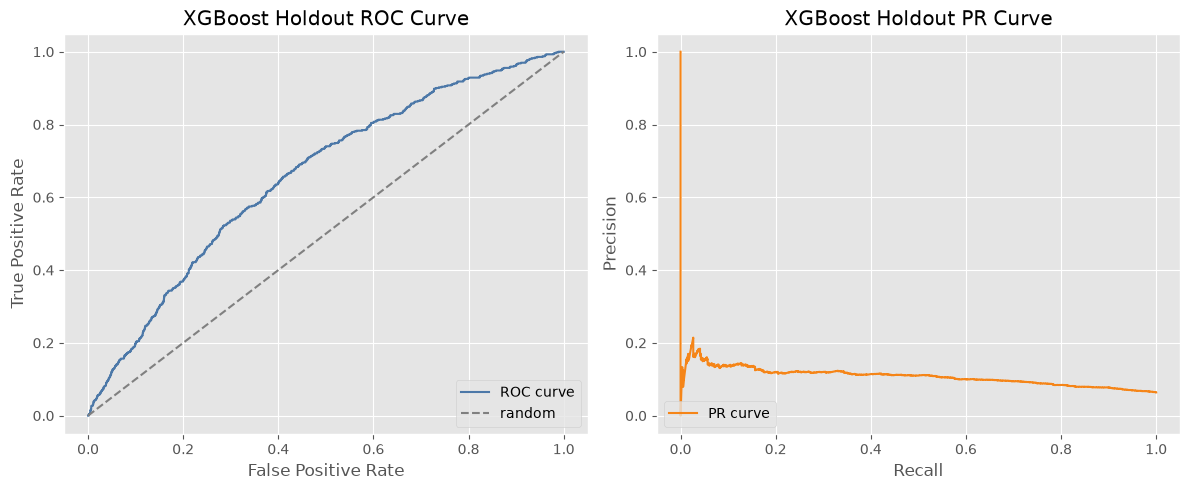

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
eng.plot_roc_curve(xgb_search['holdout_evaluation']['roc_curve'], axes[0], 'XGBoost Holdout ROC Curve')
eng.plot_precision_recall_curve(xgb_search['holdout_evaluation']['precision_recall_curve'], axes[1], 'XGBoost Holdout PR Curve')
plt.tight_layout()

## Phase 5 - Feature Importance

In [8]:
display(gain_importance)
display(weight_importance)
display(shap_importance)

,feature,importance,importance_type
0,cylinder,102.839966,gain
1,displacement,85.276352,gain
2,gross_weight,76.485298,gain
3,age_of_car,67.514114,gain
4,policy_tenure,61.777992,gain
5,steering_type__Power,61.055260,gain
6,turning_radius,60.127846,gain
7,height,48.515507,gain
8,is_parking_sensors,41.132019,gain
9,is_esc,38.346214,gain


,feature,importance,importance_type
0,policy_tenure,368.0,weight
1,age_of_car,265.0,weight
2,age_of_policyholder,252.0,weight
3,population_density,104.0,weight
4,area_cluster__freq,94.0,weight
5,displacement,32.0,weight
6,gross_weight,30.0,weight
7,model__freq,25.0,weight
8,height,19.0,weight
9,safety_feature_count,15.0,weight


,feature,mean_abs_shap
0,policy_tenure,0.407305
1,age_of_car,0.201528
2,age_of_policyholder,0.079879
3,area_cluster__freq,0.060678
4,population_density,0.057839
5,displacement,0.046130
6,gross_weight,0.040871
7,cylinder,0.037804
8,turning_radius,0.025695
9,height,0.021429


In [9]:
importance_compare = pd.DataFrame({
    'xgboost_gain': gain_importance['feature'].head(10).tolist(),
    'random_forest': rf_importance['feature'].head(10).tolist(),
    'pytorch_permutation': pytorch_importance['feature'].head(10).tolist(),
})
display(importance_compare)

,xgboost_gain,random_forest,pytorch_permutation
0,cylinder,policy_tenure,policy_tenure
1,displacement,age_of_car,age_of_car
2,gross_weight,age_of_policyholder,torque_nm
3,age_of_car,population_density,length
4,policy_tenure,area_cluster__freq,ncap_rating
5,steering_type__Power,vehicle_volume_proxy,power_to_weight
6,turning_radius,engine_type__freq,steering_type__Power
7,height,power_bhp,width
8,is_parking_sensors,power_to_weight,rear_brakes_type__Drum
9,is_esc,model__freq,parking_assist_score


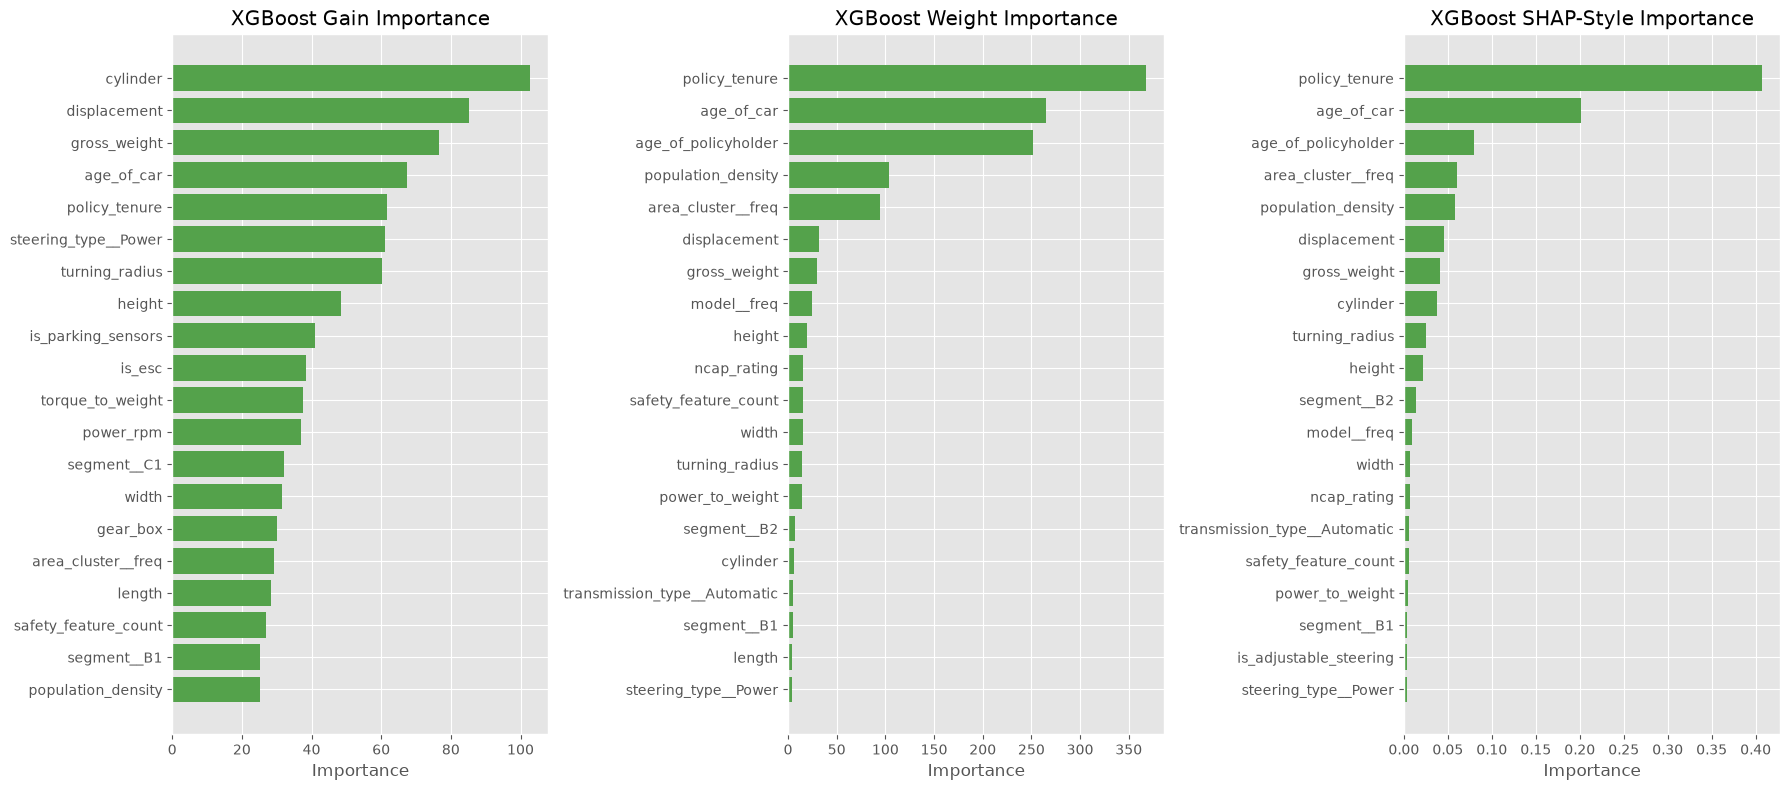

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
eng.plot_feature_importance(gain_importance.rename(columns={'importance': 'importance'}), axes[0], 'XGBoost Gain Importance')
eng.plot_feature_importance(weight_importance.rename(columns={'importance': 'importance'}), axes[1], 'XGBoost Weight Importance')
eng.plot_feature_importance(shap_importance.rename(columns={'mean_abs_shap': 'importance'}), axes[2], 'XGBoost SHAP-Style Importance')
plt.tight_layout()

Across XGBoost gain, Random Forest importance, and PyTorch permutation importance, the same policy-and-customer core appears repeatedly: `policy_tenure`, `age_of_car`, `age_of_policyholder`, `population_density`, and `area_cluster__freq`. XGBoost leans more heavily into engine/vehicle-configuration splits, while PyTorch gives slightly more prominence to ratio and safety-proxy features.

## Phase 6 - Business Interpretation

In [11]:
display(xgb_risk['risk_band_summary'])
display(domain_summary)
display(xgb_risk['feature_deltas'].head(20))

,risk_band,rows,average_predicted_probability,actual_claim_rate
0,top_decile,879,0.688443,0.118316
1,bottom_decile,879,0.142578,0.025028


,feature,high_risk_mean,low_risk_mean,difference,abs_difference,domain
0,policy_tenure,0.355954,-1.166075,1.522028,1.522028,policy
1,age_of_car,-0.801335,0.207166,-1.008501,1.008501,vehicle_profile
2,age_of_policyholder,0.224777,-0.161824,0.386601,0.386601,policy
3,vehicle_volume_proxy,-0.311098,0.001455,-0.312553,0.312553,vehicle_profile
4,height,-0.273870,0.025639,-0.299509,0.299509,vehicle_profile
5,ncap_rating,-0.266998,0.030855,-0.297853,0.297853,safety
6,population_density,-0.065676,0.231472,-0.297148,0.297148,vehicle_profile
7,power_bhp,-0.304409,-0.012800,-0.291609,0.291609,vehicle_profile
8,power_to_weight,-0.313811,-0.023512,-0.290299,0.290299,vehicle_profile
9,model__freq,0.210004,-0.079507,0.289512,0.289512,vehicle_profile


,feature,high_risk_mean,low_risk_mean,difference,abs_difference
0,policy_tenure,0.355954,-1.166075,1.522028,1.522028
1,age_of_car,-0.801335,0.207166,-1.008501,1.008501
2,age_of_policyholder,0.224777,-0.161824,0.386601,0.386601
3,vehicle_volume_proxy,-0.311098,0.001455,-0.312553,0.312553
4,height,-0.273870,0.025639,-0.299509,0.299509
5,ncap_rating,-0.266998,0.030855,-0.297853,0.297853
6,population_density,-0.065676,0.231472,-0.297148,0.297148
7,power_bhp,-0.304409,-0.012800,-0.291609,0.291609
8,power_to_weight,-0.313811,-0.023512,-0.290299,0.290299
9,model__freq,0.210004,-0.079507,0.289512,0.289512


For insurance agents and underwriters, XGBoost describes a familiar high-risk pattern: longer-tenure policies, older policyholders, and smaller or lighter vehicle configurations occur more often in the higher-risk band. Lower-risk profiles show stronger safety proxies, larger physical vehicle dimensions, and lower cluster-density exposure. These are observed portfolio patterns, not causal rules.

## Phase 7 - Final Benchmark Comparison

In [12]:
display(comparison)
display(eng.model_ranking_table(comparison))
display(leaderboard)

,model,status,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,Evaluated,0.564178,0.086538,0.608541,0.151529,0.609487,0.084656
1,Decision Tree,Evaluated,0.546427,0.091213,0.679715,0.160842,0.649624,0.134058
2,Random Forest,Evaluated,0.590692,0.096302,0.644128,0.167554,0.662448,0.110513
3,XGBoost,Evaluated,0.587392,0.097900,0.663701,0.170631,0.657401,0.106928
4,PyTorch Neural Net,Evaluated,0.492945,0.086975,0.729537,0.155421,0.655324,0.104620


,rank,model,status,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,Decision Tree,Evaluated,0.546427,0.091213,0.679715,0.160842,0.649624,0.134058
1,2,Random Forest,Evaluated,0.590692,0.096302,0.644128,0.167554,0.662448,0.110513
2,3,XGBoost,Evaluated,0.587392,0.097900,0.663701,0.170631,0.657401,0.106928
3,4,PyTorch Neural Net,Evaluated,0.492945,0.086975,0.729537,0.155421,0.655324,0.104620
4,5,Logistic Regression,Evaluated,0.564178,0.086538,0.608541,0.151529,0.609487,0.084656


,category,model
0,Best ROC-AUC,Random Forest
1,Best Recall,PyTorch Neural Net
2,Best Precision,XGBoost
3,Best PR-AUC,Decision Tree
4,Most Explainable Model,Logistic Regression


## Phase 8 - Statistical Comparison

In [13]:
display(bootstrap)

,metric_name,observed_difference,bootstrap_mean_difference,ci_lower,ci_upper,n_bootstrap,statistically_meaningful
0,roc_auc,-0.005046,-0.004812,-0.017166,0.006131,500,False
1,pr_auc,-0.003585,-0.003595,-0.012778,0.003723,500,False


The holdout bootstrap comparison shows that XGBoost does **not** meaningfully outperform Random Forest on either `ROC-AUC` or `PR-AUC`; both confidence intervals cross zero.

## Phase 9 - Production Recommendation

In [14]:
recommendation = pd.DataFrame([
    {
        'question': 'Should Random Forest remain the production candidate?',
        'answer': 'Yes',
        'detail': 'Random Forest still leads holdout ROC-AUC and remains statistically indistinguishable from XGBoost while being simpler in the current project context.'
    },
    {
        'question': 'Should XGBoost replace Random Forest?',
        'answer': 'No',
        'detail': 'XGBoost improved precision and F1 slightly, but not enough to overcome the ROC-AUC and PR-AUC gap versus Random Forest.'
    },
    {
        'question': 'Is the improvement meaningful enough to justify replacement?',
        'answer': 'No',
        'detail': 'Bootstrap confidence intervals for ROC-AUC and PR-AUC differences both cross zero.'
    },
    {
        'question': 'Which model should advance to Sprint 6 Final Model Freeze?',
        'answer': 'Random Forest',
        'detail': 'It remains the strongest overall production candidate on the frozen Sprint 3 dataset.'
    },
])
display(recommendation)

,question,answer,detail
0,Should Random Forest remain the production can...,Yes,Random Forest still leads holdout ROC-AUC and ...
1,Should XGBoost replace Random Forest?,No,"XGBoost improved precision and F1 slightly, bu..."
2,Is the improvement meaningful enough to justif...,No,Bootstrap confidence intervals for ROC-AUC and...
3,Which model should advance to Sprint 6 Final M...,Random Forest,It remains the strongest overall production ca...


Sprint 5.5 stops here. No API work was started, no frontend work was started, and Sprint 6 was not started.